# Multi-Agent Workflows with LangGraph

This notebook explores how to design and implement **multi-agent workflows** using LangGraph.

It covers:
- Core concepts behind graph-based orchestration
- Different architectural approaches to multi-agent systems
- Practical examples demonstrating how agents coordinate, share state, and make decisions
- Comparisons with simpler chain-based designs to highlight when LangGraph is the better choice

The goal is to build an intuition for **stateful, controllable, and production-ready AI workflows** rather than simple linear chains.

## LangChain vs LangGraph

**LangChain** → build with LLMs, prompts, tools, and simple chains.  
**LangGraph** → control how those pieces run using a stateful graph.

| | LangChain | LangGraph |
|---|---|---|
| Purpose | Compose LLM components | Orchestrate workflow |
| Flow | Linear / agent-driven | Graph with branches & loops |
| State | Implicit memory | Explicit shared state |
| Best for | RAG, chatbots, prototypes | Multi-agent, complex logic, production |

**Together:** use LangChain for components, LangGraph for control.

## Main Problem with Agents Built Only with LangChain

The core issue is **lack of explicit control over the execution flow** as complexity grows.

> Control flow lives inside the LLM instead of your code.

**What this causes**

- **Non-deterministic behavior** – same input, different tool paths
- **Hidden execution loop** – hard to add guards, retries, or branches
- **Weak state management** – mostly unstructured chat history
- **Hard to debug** – no clear step-by-step workflow trace
- **“Prompt spaghetti”** – logic starts leaking into prompts

**Why it matters**

LangChain agents are great for quick demos, but in real systems you need:

> “We define what can happen next,” not “the LLM decides what to do next.”

## The Single-Agent Problem

A single LLM agent struggles to:
- Keep detail **and** big-picture context
- Handle complex, step-by-step tasks reliably
- Scale logic to new problems

### Solution — Multi-Agent Systems

Use multiple specialized agents that:
- Divide responsibilities
- Collaborate and validate each other
- Make the workflow easier to control and debug

This makes LLM systems more **scalable, reliable, and manageable**.

LangGraph is well-suited to orchestrate this interaction.

---

## What Is an Agent?

An **agent** is not just an LLM.

> **Agent = LLM + role + tools + action logic**

**Components:**
- LLM
- System prompt (role)
- Tools (APIs, search, code, DB, etc.)
- Optional memory

The agent has a **goal**, decides **which tools to use**, and **plans steps** to complete the task.

## LangChain and LangGraph for Multi-Agent Systems

**LangChain** helps you build with LLMs, tools, prompts, and memory.  
**LangGraph** lets you organize complex, multi-step logic as a **state graph**.

### What LangGraph adds
- Nodes = agents, tools, or steps
- Edges = control flow between them
- Loops, conditions, and long-term state
- Human-in-the-loop when needed

LangGraph can be used **with or without** LangChain.

---

In this notebook, we’ll build several multi-agent examples with LangGraph, from simple cooperation to workflows with branching and loops.

# Practice Examples

## Environment setup

Set API keys as environment variables:

- LangSmith tracing → `LANGSMITH_API_KEY`
- OpenAI API → `OPENAI_API_KEY`
- Tavily Search → `TAVILY_API_KEY`

We will use LangSmith to observe how the agent thinks, calls tools, and produces results.

In [1]:
import os

os.environ["LANGSMITH_TRACING"], os.environ["LANGSMITH_ENDPOINT"], os.environ["LANGSMITH_PROJECT"]

('true', 'https://api.smith.langchain.com', 'multi-agents project')

## Simple Solo Agent with Web Search (LangChain)

Start with a basic single agent that can search the web using Tavily.
This example shows the typical LangChain agent pattern before moving to LangGraph.

In [7]:
from langchain_classic import hub
from langchain_classic.agents import AgentExecutor
from langchain_classic.agents.format_scratchpad.openai_tools import (
    format_to_openai_tool_messages,
)
from langchain_classic.agents.output_parsers.openai_tools import (
    OpenAIToolsAgentOutputParser,
)
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI

# Pull agent prompt from LangChain Hub
prompt = hub.pull("wfh/langsmith-agent-prompt:5d466cbc")

# LLM
llm = ChatOpenAI(model="gpt-4o-mini")

# Tool: Tavily web search
tools = [
    TavilySearchResults(name="tavily_search"),
]

# Bind tools to LLM
llm_with_tools = llm.bind_tools(tools)

# Classic LangChain OpenAI-tools agent pattern
runnable_agent = (
    {
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: format_to_openai_tool_messages(
            x["intermediate_steps"]
        ),
    }
    | prompt
    | llm_with_tools
    | OpenAIToolsAgentOutputParser()
)

agent_executor = AgentExecutor(
    agent=runnable_agent,
    tools=tools,
    handle_parsing_errors=True,
)

# Example run
agent_executor.invoke(
    {"input": "What is the average salary for software engineers in Ukraine in 2026?"}
)

{'input': 'What is the average salary for software engineers in Ukraine in 2026?',
 'output': 'In 2026, the average salary for software engineers in Ukraine is around **UAH 2,217,926** (approximately USD 59,176 based on current exchange rates). The salary range for software engineers varies, with typical earnings between **UAH 1,376,644** to **UAH 2,931,741** depending on factors like experience and specialization.\n\n### Breakdown of Salaries for Specific Roles (2026):\n- **Java Developer:** $69,000\n- **Python Developer:** $72,000\n- **PHP Developer:** $55,200\n- **C++ Developer:** $69,600\n- **AI Engineer:** $69,000\n- **Mobile Developer (iOS/Android):** $72,000\n- **Game Developer:** $42,000\n\nUkrainian software engineers are generally 1.5 times more competitive in salary compared to Western Europe and about half the cost of hiring engineers in the US. Despite the ongoing challenges in the region, the demand for technical talent remains strong.\n\nFor more detailed information, yo

https://smith.langchain.com/public/c491974e-e8ec-4bbc-95fb-a1a89a01e180/r

## Simple Solo Agent with Web Search (LangGraph)

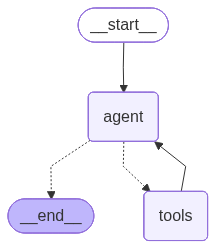

In [9]:
# Simple Solo Agent with Web Search (LangGraph)

from typing import Literal
from IPython.display import Image, display

# Core LangChain + LangGraph imports
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

# ------------------------------
# 1️⃣ Define a search tool
# ------------------------------

# uncomment to mock search tool
# @tool
# def search(query: str):
#     """
#     Placeholder web search tool.
#     """
#     # Example logic for demonstration
#     if "sf" in query.lower() or "san francisco" in query.lower():
#         return "It's 60 degrees and foggy."
#     return "It's 90 degrees and sunny."

# real search
tavily_search = TavilySearchResults(name="tavily_search")
@tool
def search(query: str):
    """Call to surf the web."""
    return tavily_search.run(query)

tools = [search]

# Wrap tools in a ToolNode (prebuilt LangGraph node)
tool_node = ToolNode(tools)

# ------------------------------
# 2️⃣ Define the agent (LLM)
# ------------------------------

# Bind the LLM to the tools
model = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(tools)

def call_model(state: MessagesState):
    """
    Node function for the agent.
    Receives conversation state, calls the LLM, returns updated messages.
    """
    messages = state['messages']
    response = model.invoke(messages)  # auto-detects context + tools
    return {"messages": [response]}

# ------------------------------
# 3️⃣ Define workflow logic
# ------------------------------

def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """
    Conditional function to check if the agent wants to use a tool.
    If so, continue to the 'tools' node, else end.
    """
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:  # if LLM decided to call a tool
        return "tools"
    return "__end__"

# Initialize workflow
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Define edges
workflow.add_edge("__start__", "agent")          # start → agent
workflow.add_conditional_edges("agent", should_continue)  # agent → tools (if needed)
workflow.add_edge("tools", "agent")             # tools → agent (loop back)

# Compile workflow
graph = workflow.compile()

# ------------------------------
# 4️⃣ Visualize workflow
# ------------------------------
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
from langchain_core.messages import HumanMessage

final_state = graph.invoke(
    {"messages": [HumanMessage(content="what is the weather in kyiv")]},
    config={"configurable": {"thread_id": 42}}
)
final_state["messages"][-1].content

'The current weather in Kyiv is overcast with a temperature of approximately 7°C (45°F). The humidity is around 62%, and there is a light wind coming from the west at about 9 mph. The forecast indicates a high of 8°C (47°F) and a low of 3°C (37°F) for today. \n\nFor more detailed information, you can check the full weather report [here](https://www.timeanddate.com/weather/ukraine/kyiv).'

https://smith.langchain.com/public/c881550c-4099-4a92-8010-ffe5789e4654/r

## Multi-Agent Examples

Here are three examples of multi-agent workflows. These illustrate some common patterns, but real-world scenarios can vary widely.

### Define Tools
Define some tools that our agents will use in the future

In [ ]:
# !pip install langchain_tavily --quiet

In [ ]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearch(max_results=5)

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

## Multi-Agent Collaboration

In this example, agents collaborate via a **shared scratchpad of messages**. All steps are visible to other agents, which allows transparency but can sometimes be overly verbose. In some cases, only the final answer is needed.

**Agents:**  
Each agent is a single LLM call with a specific prompt template and system message.

**Connections:**  
- Controlled by a simple **rule-based router**.  
- After each LLM call:
  - If a tool is invoked → call the tool  
  - If LLM responds with `"FINAL ANSWER"` → return to user  
  - Otherwise → pass control to the next LLM

**Visualization:**  

![](https://storage.ghost.io/c/97/88/97889716-a759-46f4-b63f-4f5c46a13333/content/images/size/w1000/2024/01/simple_multi_agent_diagram--1-.png)

### Create graph
Now that we've defined our tools and made some helper functions, will create the individual agents below and tell them how to talk to each other using LangGraph.

#### Define Agent Nodes
We now need to define the nodes.

First, we'll create a utility to create a system prompt for each agent.

In [17]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [23]:
from typing import Literal

from langchain_core.messages import BaseMessage, HumanMessage
# from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command


llm = ChatOpenAI(model="gpt-4o-mini")


def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto


# Research agent and node
research_agent = create_agent(
    llm,
    tools=[tavily_tool],
    system_prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)


def research_node(
    state: MessagesState,
) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


# Chart generator agent and node
# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION, WHICH CAN BE UNSAFE WHEN NOT SANDBOXED
chart_agent = create_agent(
    llm,
    [python_repl_tool],
    system_prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)


def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )
    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

#### Define the Graph

We can now put it all together and define the graph!

In [24]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()

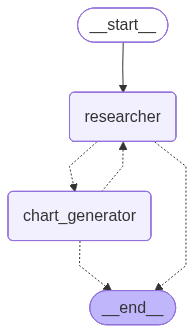

In [25]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### Invoke

With the graph created, you can invoke it! Let's have it chart some stats for us.

{'researcher': {'messages': [HumanMessage(content="First, get the UK's GDP over the past 5 years, then make a line chart of it. Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='15901c03-f897-4f79-a810-edd9f6c479c2'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1316, 'total_tokens': 1343, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5e5eb987d2', 'id': 'chatcmpl-DS1N4VLNShmHMkvaJ5M1h4T5Y66vH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6844-b4f3-7241-85a7-9aac9c56221b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'UK GDP data past 5 years', 'search_de

Python REPL can execute arbitrary code. Use with caution.


{'chart_generator': {'messages': [HumanMessage(content="First, get the UK's GDP over the past 5 years, then make a line chart of it. Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='15901c03-f897-4f79-a810-edd9f6c479c2'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1316, 'total_tokens': 1343, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5e5eb987d2', 'id': 'chatcmpl-DS1N4VLNShmHMkvaJ5M1h4T5Y66vH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6844-b4f3-7241-85a7-9aac9c56221b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'UK GDP data past 5 years', 'sear

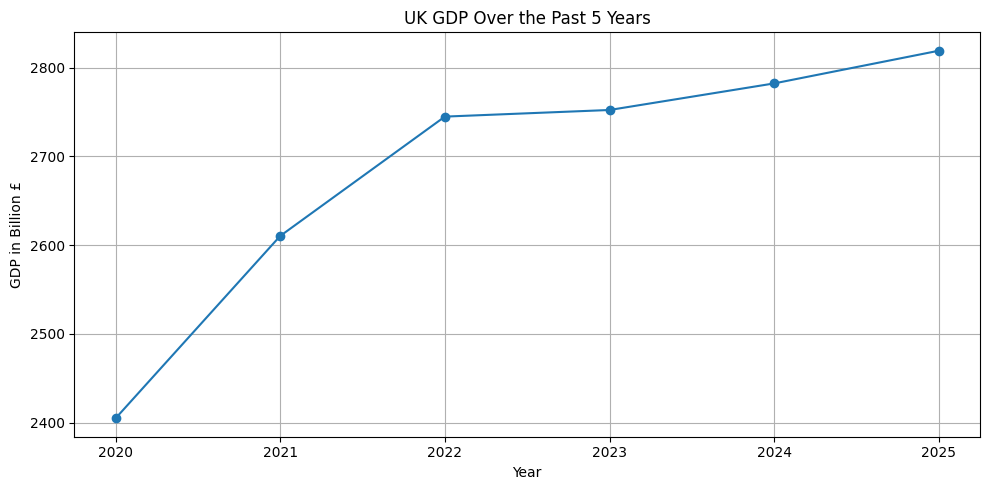

In [27]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "First, get the UK's GDP over the past 5 years, then make a line chart of it. "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 15},
)
for s in events:
    print(s)
    print("----")

https://smith.langchain.com/public/e5c08f5f-0579-428f-a187-89edcf02d979/r

## Agent Supervisor

In this example, agents have **independent scratchpads**. Their final responses are appended to a **global scratchpad**, rather than sharing all intermediate steps.

**Agents:**  
Each agent is a full LangChain agent with its own prompt, LLM, and tools, executed via `AgentExecutor`.

**Connections:**  
An **agent supervisor** routes requests to individual agents.  
Think of the supervisor as an agent whose **tools are other agents**.

**Visualization:**  

![](https://storage.ghost.io/c/97/88/97889716-a759-46f4-b63f-4f5c46a13333/content/images/size/w1000/2024/01/supervisor-diagram.png)

In [28]:
from typing import Literal
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# ------------------------------
# 1️⃣ Define team members and options
# ------------------------------

members = ["researcher", "coder"]
# The supervisor can choose the next agent or decide to finish
options = members + ["FINISH"]

# System prompt for the supervisor agent
system_prompt = (
    "You are a supervisor, responsible for managing the conversation between"
    f" the following team members: {members}. Based on the user's request, "
    "decide which member should act next. Each member will perform their task "
    "and return results and status. When the work is complete, respond with FINISH."
)

# ------------------------------
# 2️⃣ Structured output type
# ------------------------------

class Router(TypedDict):
    """
    The supervisor outputs the next agent to run.
    If no more agents are needed, route to FINISH.
    """
    next: Literal[*options]

# ------------------------------
# 3️⃣ Initialize LLM
# ------------------------------

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

# ------------------------------
# 4️⃣ Define custom state
# ------------------------------

class State(MessagesState):
    """Extends MessagesState to track the next agent to run."""
    next: str

# ------------------------------
# 5️⃣ Supervisor node
# ------------------------------

def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
    """
    Supervisor workflow node.
    - Receives the conversation state
    - Calls the LLM to decide which agent goes next
    - Returns a Command with the next node (or END if finished)
    """
    # Prepend system prompt to current messages
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]

    # Ask LLM to select next agent
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]

    # Map FINISH to END for LangGraph workflow
    if goto == "FINISH":
        goto = END

    # Return updated state and next node
    return Command(goto=goto, update={"next": goto})

### Build Graph

In [30]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
# from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent


research_agent = create_agent(
    llm, tools=[tavily_tool], system_prompt="You are a researcher. Do NOT perform any mathematical calculations."
)


def research_node(state: State) -> Command[Literal["supervisor"]]:
    result = research_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )


code_agent = create_agent(llm, tools=[python_repl_tool])


def code_node(state: State) -> Command[Literal["supervisor"]]:
    result = code_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )


builder = StateGraph(State)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("coder", code_node)
graph = builder.compile()

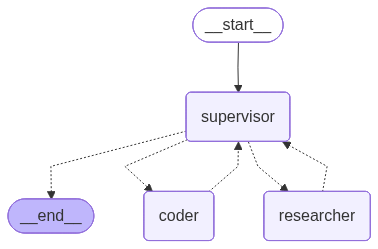

In [32]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [38]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2025. What the root square from % of US GDP was New York state?",
            }
        ],
    },
    subgraphs=True,
):
    print(chunk)
    print("----")
    


((), {'supervisor': {'next': 'researcher'}})
----
(('researcher:7958eb82-627e-bfd7-1fa4-ca29d9892cae',), {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 1225, 'total_tokens': 1295, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_df209e7bf8', 'id': 'chatcmpl-DS1lhfuBMHIAxWErpcB9G3dNVqtaq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d685b-fffa-70f2-9706-1b2f9e00bea6-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'US GDP 2025 forecast', 'search_depth': 'advanced'}, 'id': 'call_fyCkGVTL5CK991lgNIh8wfas', 'type': 'tool_call'}, {'name': 'tavily_search', 'args': {'query': 'N

https://smith.langchain.com/public/a1f7e896-d125-4f3d-a311-aca7715affc8/r

## Hierarchical Agent Teams

This example builds on the previous supervisor workflow, but now the agents in each node are **other LangGraph workflows** themselves.  

This setup allows **more flexibility** than using a LangChain `AgentExecutor` for runtime.  
We call this **hierarchical teams** because each sub-agent can be thought of as a mini-team.

**Agents:**  
Each node contains a full LangGraph agent (sub-workflow).

**Connections:**  
A **supervisor agent** orchestrates and routes between the sub-agents.

**Visualization:**  

![](https://storage.ghost.io/c/97/88/97889716-a759-46f4-b63f-4f5c46a13333/content/images/size/w1000/2024/01/hierarchical-diagram.png)

### Create Tools
Each team will be composed of one or more agents each with one or more tools. Below, define all the tools to be used by your different teams.

We'll start with the research team.

#### ResearchTeam tools

The research team can use a search engine and url scraper to find information on the web. Feel free to add additional functionality below to boost the team performance!

In [39]:
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

tavily_tool = TavilySearch(max_results=5)


@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


#### Document writing team tools

Next up, we will give some tools for the doc writing team to use. We define some bare-bones file-access tools below.

Note that this gives the agents access to your file-system, which can be unsafe. We also haven't optimized the tool descriptions for performance.

In [61]:
from pathlib import Path
# from tempfile import TemporaryDirectory
from typing import Dict, Optional

from langchain_experimental.utilities import PythonREPL
from typing_extensions import TypedDict

# _TEMP_DIRECTORY = TemporaryDirectory()
# WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)
WORKING_DIRECTORY = Path(os.getcwd()) / "data"


@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

### Helper Utilities
We are going to create a few utility functions to make it more concise when we want to:

1. Create a worker agent.
2. Create a supervisor for the sub-graph.

These will simplify the graph compositional code at the end for us so it's easier to see what's going on.

In [43]:
from typing import List, Optional, Literal
from langchain_core.language_models.chat_models import BaseChatModel

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages


class State(MessagesState):
    next: str


def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

### Define Agent Teams
Now we can get to define our hierarchical teams. "Choose your player!"

#### Research Team
The research team will have a search agent and a web scraping "research_agent" as the two worker nodes. Let's create those, as well as the team supervisor.

In [44]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
# from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent

llm = ChatOpenAI(model="gpt-4o")

search_agent = create_agent(llm, tools=[tavily_tool])


def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="search")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


web_scraper_agent = create_agent(llm, tools=[scrape_webpages])


def web_scraper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scraper_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="web_scraper")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


research_supervisor_node = make_supervisor_node(llm, ["search", "web_scraper"])

Now that we've created the necessary components, defining their interactions is easy. Add the nodes to the team graph, and define the edges, which determine the transition criteria.

In [45]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scraper", web_scraper_node)

research_builder.add_edge(START, "supervisor")
research_graph = research_builder.compile()

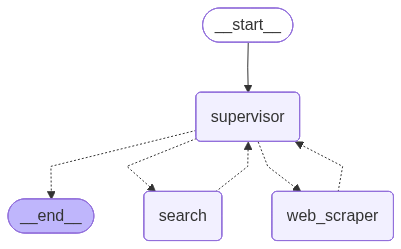

In [46]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))

In [47]:
for s in research_graph.stream(
    {"messages": [("user", "when is Taylor Swift's next tour?")]},
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'search'}}
---
{'search': {'messages': [HumanMessage(content='Taylor Swift\'s "Eras Tour," which began in March 2023 and included U.S. dates, wrapped up its initial U.S. leg in August 2023. However, Taylor Swift has added more U.S. show dates for 2024. These include:\n\n- Miami from October 18-20, 2024\n- New Orleans from October 25-27, 2024\n- Indianapolis from November 1-3, 2024\n\nThe tour will also continue internationally, with scheduled stops in countries such as Japan, Australia, Singapore, France, Sweden, Portugal, Spain, Ireland, the Netherlands, Switzerland, Italy, Germany, Poland, and Austria. Several shows will also take place in the UK, including dates in June in Edinburgh, Liverpool, Cardiff, and three consecutive nights at Wembley Stadium in London.', additional_kwargs={}, response_metadata={}, name='search', id='63069930-39d1-40d7-b582-adac45942351')]}}
---
{'supervisor': {'next': '__end__'}}
---


#### Document Writing Team
Create the document writing team below using a similar approach. This time, we will give each agent access to different file-writing tools.

Note that we are giving file-system access to our agent here, which is not safe in all cases.

In [48]:
llm = ChatOpenAI(model="gpt-4o")

doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt=(
        "You can read, write and edit documents based on note-taker's outlines. "
        "Don't ask follow-up questions."
    ),
)


def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="doc_writer")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    ),
)


def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="note_taker")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


chart_generating_agent = create_agent(
    llm, tools=[read_document, python_repl_tool]
)


def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=result["messages"][-1].content, name="chart_generator"
                )
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


doc_writing_supervisor_node = make_supervisor_node(
    llm, ["doc_writer", "note_taker", "chart_generator"]
)

With the objects themselves created, we can form the graph.

In [49]:
# Create the graph here
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.add_edge(START, "supervisor")
paper_writing_graph = paper_writing_builder.compile()

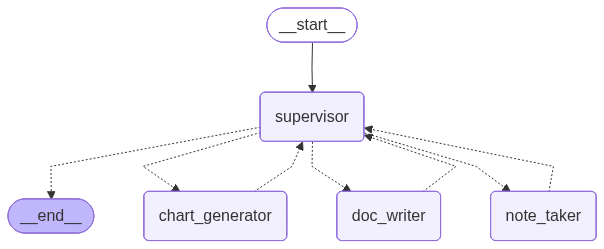

In [50]:
from IPython.display import Image, display

display(Image(paper_writing_graph.get_graph().draw_mermaid_png()))

In [67]:
for s in paper_writing_graph.stream(
    {
        "messages": [
            (
                "user",
                "Write an outline for poem about cats. Then based on outline write the poem to disk.",
            )
        ]
    },
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'note_taker'}}
---
{'note_taker': {'messages': [HumanMessage(content='The outline for the poem about cats has been saved to "poem_about_cats.txt". ', additional_kwargs={}, response_metadata={}, name='note_taker', id='8a8851a0-9793-4290-b1ca-086dea4df963')]}}
---
{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='The poem about cats has been written based on the outline and saved as "poem_cats.txt".', additional_kwargs={}, response_metadata={}, name='doc_writer', id='0629377a-c21c-4cce-bfb1-b0733be809d3')]}}
---
{'supervisor': {'next': '__end__'}}
---


https://smith.langchain.com/public/5005acd1-47af-471f-9f91-3d66b31c7b9e/r

### Add Layers
In this design, we are enforcing a top-down planning policy. We've created two graphs already, but we have to decide how to route work between the two.

We'll create a third graph to orchestrate the previous two, and add some connectors to define how this top-level state is shared between the different graphs.

In [68]:
from langchain_core.messages import BaseMessage

llm = ChatOpenAI(model="gpt-4o")

teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

In [69]:
def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor",
    )


def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor",
    )


# Define the graph.
super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

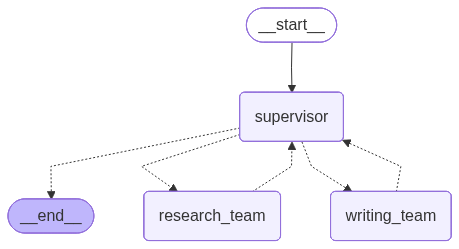

In [70]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))

In [71]:
for s in super_graph.stream(
    {
        "messages": [
            ("user", "Research AI agents and write a brief report about them.")
        ],
    },
    {"recursion_limit": 150},
):
    print(s)
    print("---")

{'supervisor': {'next': 'research_team'}}
---
{'research_team': {'messages': [HumanMessage(content="### AI Agents: Latest Research and Developments\n\n#### Overview\nAI agents, which are autonomous software systems capable of performing tasks and making decisions without human intervention, have become a crucial component in various industries. Recent research and advancements in AI agents continue to evolve, defining new roles and applications in sectors from business to healthcare.\n\n#### Emerging Trends\n1. **Autonomous and Collaborative AI**: Current developments position AI agents as partners rather than just tools. Microsoft's Copilot and experimental embodied AI robots showcase how AI agents manage real-time applications, whether in enterprise systems or physical settings like warehouse management.\n\n2. **AI in Research and Industry**: AI agents are transforming research practices, handling tasks from data collection to deriving insightful discoveries. They also enable busines

https://smith.langchain.com/public/90a39ba2-d5b5-46d0-86c9-80c330eedd4a/r

# Summary of Approaches

| Approach | How Agents Interact | Memory | Key Element |
|----------|-------------------|--------|-------------|
| Collaboration | Shared scratchpad | Global | Direct message exchange |
| Supervisor | Independent agents + global scratchpad | Local + global | Supervisor as router |
| Hierarchical Teams | Subgraphs as agents | Local + subgraph | Supervisor + nested subgraphs |

# References & Next Steps

### Resources
- [LangGraph: Multi-Agent Workflows](https://blog.langchain.com/langgraph-multi-agent-workflows/) – Blog introducing LangGraph and multi-agent examples.  
- [LangChain Multi-Agent Docs](https://docs.langchain.com/oss/python/langchain/multi-agent/index) – Official guide on building multi-agent systems.

### Next Steps
- Experiment with notebook examples: modify agents, prompts, and tools.  
- Add new tools (web search, Python, database) and see interactions.  
- Explore hierarchical workflows and routing logic.  
- Use LangSmith/logging to monitor agent decisions.  
- Follow official docs/blog for updates and best practices.